# 01. Od macierzy odległości do grafów i algorytmów ML

**Czas podstawowy:** około 75–90 minut  
**Tryb pracy:** krótko policz ręcznie → uzupełnij `TODO` → uruchom autotest → zinterpretuj wynik.

## Cele

Po tym notebooku powinieneś umieć przejść przez ciąg:

$$
X\longrightarrow D\longrightarrow A_\varepsilon/A_{kNN}
\longrightarrow W\longrightarrow G
$$

oraz wyjaśnić, skąd biorą się:

- DBSCAN — z sąsiedztwa $\varepsilon$,
- kNN — z uporządkowanych odległości do sąsiadów,
- k-means — z macierzy odległości punkt–centroid,
- MDS, t-SNE i UMAP — z różnych sposobów zachowywania odległości lub podobieństw.

## Notacja używana w całym zestawie

| Symbol | Obiekt | Co oznacza? |
|---|---|---|
| $X$ | macierz danych $n\times p$ | wiersze są punktami, kolumny cechami |
| $D=[d_{ij}]$ | macierz odległości $n\times n$ | jak daleko leżą punkty $i,j$ |
| $A_\varepsilon$ | binarna macierz sąsiedztwa | czy $d_{ij}\leq\varepsilon$ |
| $A_{kNN}$ | macierz sąsiedztwa kNN | czy $j$ należy do $k$ najbliższych sąsiadów $i$ |
| $W=[w_{ij}]$ | ważona macierz sąsiedztwa / podobieństwa | jak silna jest lokalna relacja |
| $G$ | graf | wierzchołki = punkty, krawędzie wynikają z $A$ lub $W$ |

> **Ważne:** macierz odległości i macierz podobieństwa niosą odwrotną intuicję.  
> Duże $d_{ij}$ oznacza małe podobieństwo, a duże $w_{ij}$ — silną relację.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from IPython.display import display
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, KMeans, SpectralClustering
from sklearn.metrics import pairwise_distances, adjusted_rand_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

RANDOM_STATE = 42
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_columns", 30)

def plot_graph_on_points(X, A, labels, title):
    # Funkcja pomocnicza do rysowania; nie jest częścią TODO.
    plt.figure(figsize=(6, 4))
    for i in range(len(X)):
        for j in range(i + 1, len(X)):
            if A[i, j] > 0 or A[j, i] > 0:
                plt.plot(
                    [X[i, 0], X[j, 0]],
                    [X[i, 1], X[j, 1]],
                    linewidth=1.5, alpha=0.7
                )
    plt.scatter(X[:, 0], X[:, 1], s=120, zorder=3)
    for i, name in enumerate(labels):
        plt.text(X[i, 0] + 0.07, X[i, 1] + 0.06, name, fontsize=12)
    plt.axis("equal")
    plt.grid(alpha=0.25)
    plt.title(title)
    plt.show()

def graph_summary(A):
    G = nx.from_numpy_array(((A + A.T) > 0).astype(int))
    sizes = [len(c) for c in nx.connected_components(G)]
    return {
        "edges": G.number_of_edges(),
        "components": nx.number_connected_components(G),
        "largest_component": max(sizes),
        "mean_degree": np.asarray(A > 0).sum(axis=1).mean(),
    }

## 1. Mini-zbiór do liczenia ręcznego

Pracujemy najpierw na sześciu punktach. Zanim uruchomisz kod, policz:

$$
d(A,B),\qquad d(A,C),\qquad d(A,D).
$$

Dla odległości euklidesowej:

$$
d(x_i,x_j)=
\sqrt{\sum_{r=1}^{p}(x_{ir}-x_{jr})^2}.
$$

,x1,x2
A,0.0,0.0
B,1.0,0.0
C,0.0,1.0
D,4.0,0.0
E,5.0,0.0
F,4.0,1.0


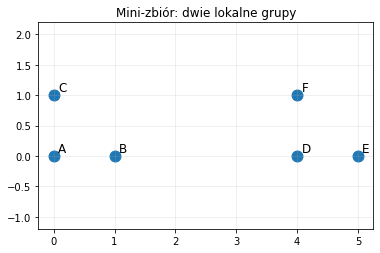

In [2]:
labels = np.array(list("ABCDEF"))
X_small = np.array([
    [0.0, 0.0],  # A
    [1.0, 0.0],  # B
    [0.0, 1.0],  # C
    [4.0, 0.0],  # D
    [5.0, 0.0],  # E
    [4.0, 1.0],  # F
])

display(pd.DataFrame(X_small, index=labels, columns=["x1", "x2"]))

plt.figure(figsize=(6, 3.8))
plt.scatter(X_small[:, 0], X_small[:, 1], s=120)
for i, name in enumerate(labels):
    plt.text(X_small[i, 0] + 0.07, X_small[i, 1] + 0.06, name, fontsize=12)
plt.axis("equal")
plt.grid(alpha=0.25)
plt.title("Mini-zbiór: dwie lokalne grupy")
plt.show()

## 2. `TODO 1` — macierz odległości $D$

Element:

$$
D_{ij}=d(x_i,x_j)
$$

opisuje odległość punktu $i$ od punktu $j$.

### Pseudokod

```text
utwórz macierz D rozmiaru n × n
dla każdego i:
    dla każdego j:
        różnica = X[i] - X[j]
        D[i,j] = pierwiastek(sumy kwadratów różnicy)
```

Po poprawnym obliczeniu:

$$
D_{ii}=0,\qquad D_{ij}=D_{ji}.
$$

### Pseudokod bliski Pythonowi

```python
# wewnątrz pętli po i oraz j:
difference = X_small[i] - X_small[j]
D_small[i, j] = np.sqrt(np.sum(difference ** 2))
```

Można też użyć równoważnego zapisu `np.linalg.norm(X_small[i] - X_small[j])`.


In [3]:
n = len(X_small)
D_small = np.zeros((n, n), dtype=float)

for i in range(n):
    for j in range(n):
        diff = X_small[i] - X_small[j]
        D_small[i, j] = np.sqrt(np.sum(diff ** 2))

In [4]:
# Autotest TODO 1
D_reference = pairwise_distances(X_small)

assert D_small is not None and np.isfinite(D_small).all(), "Uzupełnij macierz D_small."
assert D_small.shape == (len(X_small), len(X_small))
assert np.allclose(D_small, D_reference), "Macierz odległości nie zgadza się z wynikiem referencyjnym."
assert np.allclose(np.diag(D_small), 0)
assert np.allclose(D_small, D_small.T)

display(pd.DataFrame(D_small, index=labels, columns=labels).round(3))
print("✓ D jest symetryczna, a jej przekątna jest zerowa.")

,A,B,C,D,E,F
A,0.000,1.000,1.000,4.000,5.000,4.123
B,1.000,0.000,1.414,3.000,4.000,3.162
C,1.000,1.414,0.000,4.123,5.099,4.000
D,4.000,3.000,4.123,0.000,1.000,1.000
E,5.000,4.000,5.099,1.000,0.000,1.414
F,4.123,3.162,4.000,1.000,1.414,0.000


✓ D jest symetryczna, a jej przekątna jest zerowa.


## 3. `TODO 2` — macierz $\varepsilon$-sąsiedztwa

Z macierzy odległości tworzymy macierz binarną:

$$
A^\varepsilon_{ij}=
\begin{cases}
1,&0<D_{ij}\leq\varepsilon,\\
0,&\text{w przeciwnym razie}.
\end{cases}
$$

- `1` oznacza krawędź,
- `0` oznacza brak krawędzi,
- przekątna pozostaje zerowa.

To dokładnie ten obiekt, z którego korzysta intuicja DBSCAN.

### Pseudokod bliski Pythonowi

```python
condition_close = D_small <= eps_small
condition_not_diagonal = D_small > 0
A_eps_small = (condition_close & condition_not_diagonal).astype(int)
```

W wersji jednoliniowej:

```python
A_eps_small = ((D_small <= eps_small) & (D_small > 0)).astype(int)
```


In [5]:
eps_small = 1.1
A_eps_small = ((D_small <= eps_small) & (D_small > 0)).astype(int)

,A,B,C,D,E,F
A,0,1,1,0,0,0
B,1,0,0,0,0,0
C,1,0,0,0,0,0
D,0,0,0,0,1,1
E,0,0,0,1,0,0
F,0,0,0,1,0,0


{'edges': 4, 'components': 2, 'largest_component': 3, 'mean_degree': 1.3333333333333333}


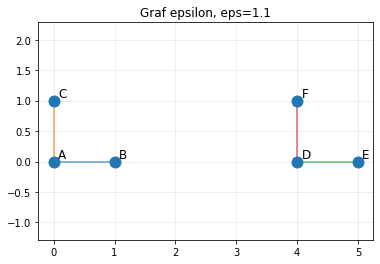

In [6]:
assert A_eps_small is not None, "Uzupełnij TODO 2."
assert set(np.unique(A_eps_small)).issubset({0, 1})
assert np.all(np.diag(A_eps_small) == 0)
assert np.all(A_eps_small == A_eps_small.T)

display(pd.DataFrame(A_eps_small, index=labels, columns=labels))
print(graph_summary(A_eps_small))
plot_graph_on_points(X_small, A_eps_small, labels, f"Graf epsilon, eps={eps_small}")

## 4. `TODO 3` — co zmienia próg $\varepsilon$?

Macierz $D$ jest stała, lecz każda wartość $\varepsilon$ tworzy inny graf.

Wraz ze wzrostem progu:

- liczba krawędzi nie maleje,
- liczba składowych spójnych nie rośnie,
- w pewnym momencie może pojawić się duża, „gigantyczna” składowa.

### Pseudokod

```text
dla każdego eps:
    zbuduj A_eps
    zamień A_eps na graf
    policz krawędzie i składowe
zapisz wyniki w tabeli
```

### Pseudokod bliski Pythonowi

```python
for eps in eps_grid_small:
    A = ((D_small <= eps) & (D_small > 0)).astype(int)
    summary = graph_summary(A)
    rows.append({"eps": eps, **summary})
```


In [7]:
eps_grid_small = np.linspace(0.5, 5.1, 47)
rows = []

for eps in eps_grid_small:
    A = ((D_small <= eps) & (D_small > 0)).astype(int)
    summary = graph_summary(A)
    rows.append({"eps": eps, **summary})

scan_small = pd.DataFrame(rows)

,eps,edges,components,largest_component,mean_degree
0,0.5,0,6,1,0.0
1,0.6,0,6,1,0.0
2,0.7,0,6,1,0.0
3,0.8,0,6,1,0.0
4,0.9,0,6,1,0.0


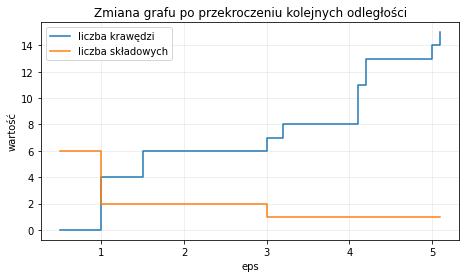

In [8]:
assert len(scan_small) == len(eps_grid_small), "Pętla nie zapisała wszystkich progów."
assert scan_small["edges"].is_monotonic_increasing
assert scan_small["components"].is_monotonic_decreasing

display(scan_small.head().round(3))

plt.figure(figsize=(7.5, 4))
plt.step(scan_small["eps"], scan_small["edges"], where="post", label="liczba krawędzi")
plt.step(scan_small["eps"], scan_small["components"], where="post", label="liczba składowych")
plt.xlabel("eps")
plt.ylabel("wartość")
plt.title("Zmiana grafu po przekroczeniu kolejnych odległości")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 5. `TODO 4–5` — graf $kNN$: kierunek, `union` i `mutual`

Dla każdego punktu wybieramy dokładnie $k$ najbliższych **innych** punktów.

$$
A^{kNN}_{ij}=1
\quad\Longleftrightarrow\quad
j\in N_k(i).
$$

Relacja jest kierunkowa: $j$ może być sąsiadem $i$, ale $i$ nie musi być sąsiadem $j$.

Dwie popularne symetryzacje:

$$
A^{union}_{ij}=1
\quad\text{gdy}\quad
A_{ij}=1\ \lor\ A_{ji}=1,
$$

$$
A^{mutual}_{ij}=1
\quad\text{gdy}\quad
A_{ij}=1\ \land\ A_{ji}=1.
$$

### Pseudokod

```text
dla każdego wiersza i macierzy D:
    posortuj indeksy według rosnącej odległości
    usuń i
    wybierz pierwszych k
    ustaw A_knn[i, wybrane] = 1
```

### Pseudokod bliski Pythonowi

```python
order = np.argsort(D_small[i])
order_without_self = order[order != i]
neighbors = order_without_self[:k_small]
A_knn_dir[i, neighbors] = 1

A_knn_union = ((A_knn_dir + A_knn_dir.T) > 0).astype(int)
A_knn_mutual = ((A_knn_dir + A_knn_dir.T) == 2).astype(int)
```


In [9]:
k_small = 1
A_knn_dir = np.zeros_like(D_small, dtype=int)

for i in range(len(D_small)):
    order = np.argsort(D_small[i])
    order = order[order != i]
    neighbors = order[:k_small]
    A_knn_dir[i, neighbors] = 1

A_knn_union = ((A_knn_dir + A_knn_dir.T) > 0).astype(int)
A_knn_mutual = ((A_knn_dir + A_knn_dir.T) == 2).astype(int)

Kierunkowy kNN


,A,B,C,D,E,F
A,0,1,0,0,0,0
B,1,0,0,0,0,0
C,1,0,0,0,0,0
D,0,0,0,0,1,0
E,0,0,0,1,0,0
F,0,0,0,1,0,0


Union kNN


,A,B,C,D,E,F
A,0,1,1,0,0,0
B,1,0,0,0,0,0
C,1,0,0,0,0,0
D,0,0,0,0,1,1
E,0,0,0,1,0,0
F,0,0,0,1,0,0


Mutual kNN


,A,B,C,D,E,F
A,0,1,0,0,0,0
B,1,0,0,0,0,0
C,0,0,0,0,0,0
D,0,0,0,0,1,0
E,0,0,0,1,0,0
F,0,0,0,0,0,0


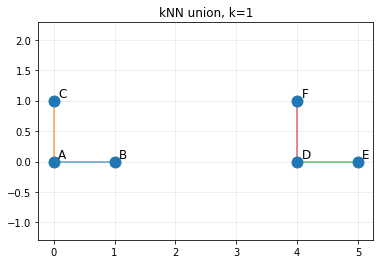

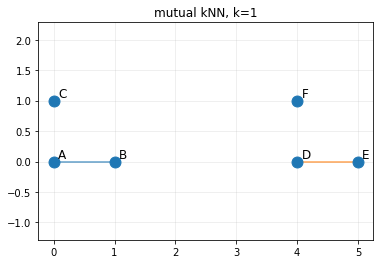

In [10]:
assert A_knn_dir.sum(axis=1).tolist() == [k_small] * len(D_small)
assert A_knn_union is not None and A_knn_mutual is not None
assert np.all(A_knn_union == A_knn_union.T)
assert np.all(A_knn_mutual == A_knn_mutual.T)
assert np.all(A_knn_mutual <= A_knn_union)

print("Kierunkowy kNN")
display(pd.DataFrame(A_knn_dir, index=labels, columns=labels))
print("Union kNN")
display(pd.DataFrame(A_knn_union, index=labels, columns=labels))
print("Mutual kNN")
display(pd.DataFrame(A_knn_mutual, index=labels, columns=labels))

plot_graph_on_points(X_small, A_knn_union, labels, "kNN union, k=1")
plot_graph_on_points(X_small, A_knn_mutual, labels, "mutual kNN, k=1")

## 6. `TODO 6` — od grafu binarnego do macierzy podobieństwa $W$

Macierz $A$ odpowiada tylko na pytanie „czy istnieje krawędź?”.  
Macierz $W$ mówi dodatkowo „jak silna jest relacja?”.

Użyjemy jądra Gaussa:

$$
W_{ij}
=
A^\varepsilon_{ij}
\exp\left(-\frac{D_{ij}^{2}}{2\sigma^{2}}\right).
$$

Własności:

- $W_{ij}=0$, gdy para nie jest sąsiedztwem,
- bliscy sąsiedzi otrzymują większą wagę,
- $\sigma$ określa tempo zaniku podobieństwa.

Stopień ważony:

$$
s_i=\sum_j W_{ij}
$$

uwzględnia zarówno liczbę sąsiadów, jak i ich bliskość.

### Pseudokod bliski Pythonowi

```python
gaussian_similarity = np.exp(-(D_small ** 2) / (2 * sigma ** 2))
W_small = A_eps_small * gaussian_similarity
np.fill_diagonal(W_small, 0)
```


In [11]:
sigma = 1.0
W_small = A_eps_small * np.exp(-(D_small ** 2) / (2 * sigma ** 2))

In [12]:
assert W_small is not None
assert W_small.shape == A_eps_small.shape
assert np.all(W_small[A_eps_small == 0] == 0)
assert np.all((W_small >= 0) & (W_small <= 1))

display(pd.DataFrame(W_small, index=labels, columns=labels).round(3))
display(pd.DataFrame({
    "punkt": labels,
    "stopien_binarny": A_eps_small.sum(axis=1),
    "stopien_wazony": W_small.sum(axis=1),
}).round(3))

,A,B,C,D,E,F
A,0.000,0.607,0.607,0.000,0.000,0.000
B,0.607,0.000,0.000,0.000,0.000,0.000
C,0.607,0.000,0.000,0.000,0.000,0.000
D,0.000,0.000,0.000,0.000,0.607,0.607
E,0.000,0.000,0.000,0.607,0.000,0.000
F,0.000,0.000,0.000,0.607,0.000,0.000


,punkt,stopien_binarny,stopien_wazony
0,A,2,1.213
1,B,1,0.607
2,C,1,0.607
3,D,2,1.213
4,E,1,0.607
5,F,1,0.607


## 7. DBSCAN jako algorytm na sąsiedztwie $\varepsilon$

Dla ustalonych `eps` i `min_samples`:

1. z macierzy $D$ wyznaczamy sąsiedztwo $\varepsilon$,
2. punkt **core** ma co najmniej `min_samples` punktów w swoim otoczeniu, licząc siebie,
3. punkt **border** nie jest `core`, ale leży w otoczeniu punktu `core`,
4. pozostałe punkty są **noise**,
5. klastry powstają przez łączenie osiągalnych punktów `core` i ich brzegów.

To ważne przejście:

$$
D\longrightarrow A_\varepsilon
\longrightarrow \text{core/border/noise}
\longrightarrow \text{klastry DBSCAN}.
$$

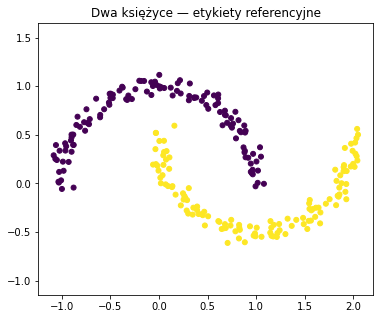

In [13]:
X_moons, y_true = make_moons(n_samples=250, noise=0.06, random_state=7)
D_moons = pairwise_distances(X_moons)

plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_true, s=25)
plt.title("Dwa księżyce — etykiety referencyjne")
plt.axis("equal")
plt.show()

### `TODO 7` — ręcznie wyznacz typ punktu DBSCAN

### Pseudokod

```text
N_eps = D <= eps
liczba_sasiadow = suma wiersza N_eps
core = liczba_sasiadow >= min_samples
border = nie core i ma przynajmniej jednego sąsiada core
noise = ani core, ani border
```

### Pseudokod bliski Pythonowi

```python
N_eps = D_moons <= eps_db                 # przekątna pozostaje True: DBSCAN liczy punkt do jego otoczenia
neighbor_count = N_eps.sum(axis=1)
is_core = neighbor_count >= min_samples
is_border = (~is_core) & N_eps[:, is_core].any(axis=1)
is_noise = ~(is_core | is_border)
```


In [14]:
eps_db = 0.18
min_samples = 5

N_eps = D_moons <= eps_db
neighbor_count = N_eps.sum(axis=1)
is_core = neighbor_count >= min_samples
is_border = (~is_core) & N_eps[:, is_core].any(axis=1)
is_noise = ~(is_core | is_border)

core     249
noise      1
Name: liczba, dtype: int64

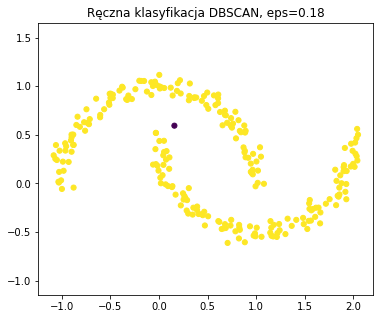

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7980ef478d30>
Traceback (most recent call last):
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_m

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7980ed2cc160>
Traceback (most recent call last):
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_m

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7980ed2cde50>
Traceback (most recent call last):
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


DBSCAN ARI: 0.992
k-means ARI: 0.243
Udział szumu DBSCAN: 0.004


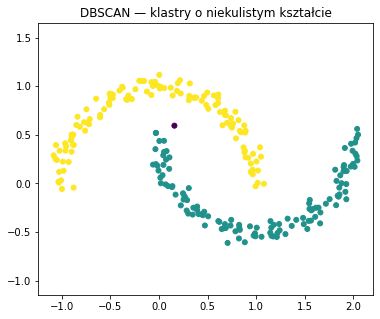

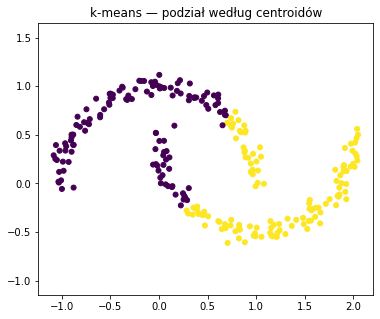

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7981787d51f0>
Traceback (most recent call last):
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_m

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7980ed2e7e50>
Traceback (most recent call last):
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/piotr/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


,metoda,ARI względem etykiet referencyjnych,czy wymaga liczby klastrów,główny obiekt
0,k-means,0.243,tak,odległości do centroidów
1,DBSCAN,0.992,nie,graf epsilon / lokalna gęstość
2,Spectral Clustering,1.000,tak,graf kNN i wektory własne laplasjanu


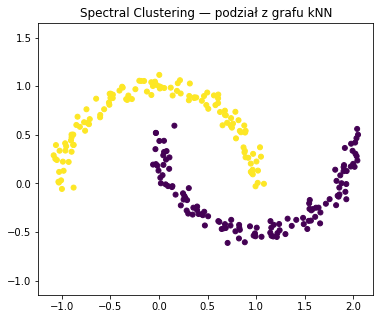

In [15]:
assert all(v is not None for v in [N_eps, neighbor_count, is_core, is_border, is_noise])
assert np.all((is_core.astype(int) + is_border.astype(int) + is_noise.astype(int)) == 1)

manual_types = np.where(is_core, "core", np.where(is_border, "border", "noise"))
display(pd.Series(manual_types).value_counts().rename("liczba"))

type_to_num = {"noise": 0, "border": 1, "core": 2}
plt.figure(figsize=(6, 5))
plt.scatter(
    X_moons[:, 0], X_moons[:, 1],
    c=[type_to_num[t] for t in manual_types], s=26
)
plt.title(f"Ręczna klasyfikacja DBSCAN, eps={eps_db}")
plt.axis("equal")
plt.show()

labels_db = DBSCAN(eps=eps_db, min_samples=min_samples).fit_predict(X_moons)
labels_km = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE).fit_predict(X_moons)

print("DBSCAN ARI:", round(adjusted_rand_score(y_true, labels_db), 3))
print("k-means ARI:", round(adjusted_rand_score(y_true, labels_km), 3))
print("Udział szumu DBSCAN:", round(np.mean(labels_db == -1), 3))

plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_db, s=25)
plt.title("DBSCAN — klastry o niekulistym kształcie")
plt.axis("equal")
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_km, s=25)
plt.title("k-means — podział według centroidów")
plt.axis("equal")
plt.show()

labels_spectral = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    n_neighbors=12,
    assign_labels="kmeans",
    random_state=RANDOM_STATE,
).fit_predict(X_moons)

comparison_moons = pd.DataFrame({
    "metoda": ["k-means", "DBSCAN", "Spectral Clustering"],
    "ARI względem etykiet referencyjnych": [
        adjusted_rand_score(y_true, labels_km),
        adjusted_rand_score(y_true, labels_db),
        adjusted_rand_score(y_true, labels_spectral),
    ],
    "czy wymaga liczby klastrów": ["tak", "nie", "tak"],
    "główny obiekt": [
        "odległości do centroidów",
        "graf epsilon / lokalna gęstość",
        "graf kNN i wektory własne laplasjanu",
    ],
})
display(comparison_moons.round(3))

plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_spectral, s=25)
plt.title("Spectral Clustering — podział z grafu kNN")
plt.axis("equal")
plt.show()



### Co pokazuje przykład z dwoma księżycami?

Ten sam zbiór może być łatwy albo trudny w zależności od **obiektu matematycznego**, na którym pracuje metoda:

| Metoda | Co zakłada lub wykorzystuje? | Wynik na księżycach |
|---|---|---|
| k-means | klastry skupione wokół centroidów | przecina łuki w niewłaściwym miejscu |
| DBSCAN | spójne obszary lokalnej gęstości w grafie $A_\varepsilon$ | zwykle dobrze odtwarza oba łuki i może oznaczyć szum |
| Spectral Clustering | graf $kNN$, laplasjan i wektory własne | dobrze radzi sobie z niekulistym kształtem, ale wymaga liczby klastrów |

To przygotowuje przejście do Isomap, Laplacian Eigenmaps i UMAP: **graf sąsiedztwa może kodować geometrię, której nie widać z samych centroidów**.

> DBSCAN i Spectral Clustering wykonują klasteryzację. MDS, t-SNE i UMAP tworzą embedding; widoczne grupy są wynikiem zachowania relacji, a nie automatycznie nadanymi etykietami.


## 8. `TODO 8` — kNN jako głosowanie po wierszu macierzy odległości

Dla nowego punktu $x_\*$:

1. liczymy odległości do wszystkich punktów treningowych,
2. wybieramy $k$ najmniejszych,
3. głosujemy etykietami wybranych sąsiadów.

$$
\widehat y(x_\*)=
\operatorname{mode}
\{y_j:j\in N_k(x_\*)\}.
$$

W odróżnieniu od grafu treningowego nie potrzebujemy pełnej macierzy $n\times n$; wystarcza jeden wektor odległości.

### Pseudokod bliski Pythonowi

```python
d_to_train = np.sqrt(np.sum((X_train - query) ** 2, axis=1))
nearest = np.argsort(d_to_train)[:k_vote]
votes = y_train[nearest]
manual_prediction = np.bincount(votes).argmax()
```


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_true,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_true
)
query = X_test[0]
k_vote = 7

In [17]:
d_to_train = np.sqrt(((X_train - query) ** 2).sum(axis=1))
order = np.argsort(d_to_train)
nearest = order[:k_vote]
manual_prediction = int(pd.Series(y_train[nearest]).mode().iloc[0])

In [18]:
assert d_to_train is not None and nearest is not None and manual_prediction is not None
assert len(nearest) == k_vote

display(pd.DataFrame({
    "odleglosc": d_to_train[nearest],
    "etykieta": y_train[nearest],
}).sort_values("odleglosc").round(3))

print("Predykcja ręczna:", manual_prediction)
print("Etykieta prawdziwa:", int(y_test[0]))

knn = KNeighborsClassifier(n_neighbors=k_vote)
knn.fit(X_train, y_train)
print("Predykcja sklearn dla tego punktu:", int(knn.predict(query.reshape(1, -1))[0]))
print("Accuracy kNN na całym zbiorze testowym:", round(knn.score(X_test, y_test), 3))

,odleglosc,etykieta
0,0.112,1
1,0.117,1
2,0.140,1
3,0.164,1
4,0.184,1
5,0.208,1
6,0.232,1


Predykcja ręczna: 1
Etykieta prawdziwa: 1
Predykcja sklearn dla tego punktu: 1
Accuracy kNN na całym zbiorze testowym: 1.0


## 9. `TODO 9` — jedna iteracja k-means

k-means nie buduje grafu. Tworzy macierz odległości:

$$
D^{X\mu}_{ic}=\lVert x_i-\mu_c\rVert
$$

pomiędzy każdym punktem $x_i$ a każdym centroidem $\mu_c$.

Jedna iteracja składa się z dwóch kroków:

1. **assignment:** przypisz punkt do najbliższego centroidu,
2. **update:** zastąp centroid średnią punktów przypisanych do klastra.

### Pseudokod bliski Pythonowi

```python
dist_to_centroids = pairwise_distances(X_small, centroids_0)
assignment = np.argmin(dist_to_centroids, axis=1)
centroids_1 = np.vstack([
    X_small[assignment == cluster_id].mean(axis=0)
    for cluster_id in range(len(centroids_0))
])
```


In [19]:
centroids_0 = np.array([
    [0.0, 0.0],
    [5.0, 0.0],
])

In [20]:
dist_to_centroids = pairwise_distances(X_small, centroids_0)
assignment = dist_to_centroids.argmin(axis=1)
centroids_1 = np.vstack([
    X_small[assignment == c].mean(axis=0)
    for c in range(len(centroids_0))
])

In [21]:
assert dist_to_centroids is not None and assignment is not None and centroids_1 is not None
assert dist_to_centroids.shape == (len(X_small), len(centroids_0))

print("Macierz odległości punkt–centroid")
display(pd.DataFrame(
    dist_to_centroids,
    index=labels,
    columns=["mu_1", "mu_2"]
).round(3))
print("Przypisania:", dict(zip(labels, assignment)))
print("Nowe centroidy:\n", np.round(centroids_1, 3))

Macierz odległości punkt–centroid


,mu_1,mu_2
A,0.000,5.000
B,1.000,4.000
C,1.000,5.099
D,4.000,1.000
E,5.000,0.000
F,4.123,1.414


Przypisania: {'A': 0, 'B': 0, 'C': 0, 'D': 1, 'E': 1, 'F': 1}
Nowe centroidy:
 [[0.333 0.333]
 [4.333 0.333]]


# Podsumowanie i przejście do redukcji wymiarowości

| Metoda | Główny obiekt | Co robi? |
|---|---|---|
| DBSCAN | $A_\varepsilon$ / otoczenia z $D$ | łączy gęstościowo osiągalne punkty |
| kNN | uporządkowane odległości | głosuje etykietami najbliższych |
| k-means | odległości punkt–centroid | minimalizuje odległości wewnątrz klastrów |
| MDS | $D^X$ | szuka $Y$, którego $D^Y$ przypomina $D^X$ |
| t-SNE | rozkład podobieństw $P$ | szuka $Y$, którego rozkład $Q(Y)$ przypomina $P$ |
| UMAP | ważony graf kNN $P$ | szuka $Y$, którego fuzzy graf $Q(Y)$ przypomina $P$ |

Najważniejszy ciąg pojęciowy:

$$
X\to D\to A/W\to P
\quad\text{oraz}\quad
Y\to D^Y\to Q(Y).
$$

W następnym notebooku zobaczymy dokładnie, czym są $P$ i $Q$ w MDS, t-SNE i UMAP oraz jakie funkcje błędu są minimalizowane.